In [4]:
import os
import shutil
from PIL import Image
from sahi.slicing import slice_image

In [5]:
def tile_dataset(input_images_dir, input_labels_dir, output_dir, grid=10,
                 overlap_ratio=0.2, min_visibility=0.1):
    """
    Slices each annotated image into a grid x grid set of tiles using SAHI and
    remaps YOLO annotations into each tile's coordinate space. Images without a
    corresponding annotation file are skipped entirely.
    Outputs Ultralytics-compatible structure: output_dir/images/ and output_dir/labels/

    Args:
        input_images_dir (str): Directory containing source images.
        input_labels_dir (str): Directory containing YOLO .txt annotation files.
        output_dir (str): Root output directory.
        grid (int): Number of tiles per side (grid x grid total tiles per image).
        overlap_ratio (float): Fractional overlap between adjacent tiles (e.g. 0.1 = 10%).
        min_visibility (float): Minimum fraction of a box's area that must fall
                                 inside a tile for it to be included (0.0 - 1.0).
    """
    supported = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}

    out_images = os.path.join(output_dir, "images")
    out_labels = os.path.join(output_dir, "labels")
    os.makedirs(out_images, exist_ok=True)
    os.makedirs(out_labels, exist_ok=True)

    classes_src = os.path.join(input_labels_dir, "classes.txt")
    if os.path.exists(classes_src):
        shutil.copy2(classes_src, os.path.join(out_labels, "classes.txt"))

    image_files = [f for f in os.listdir(input_images_dir)
                   if os.path.splitext(f)[1].lower() in supported]

    skipped = 0
    for img_file in image_files:
        stem = os.path.splitext(img_file)[0]
        ext  = os.path.splitext(img_file)[1]
        img_path = os.path.join(input_images_dir, img_file)
        txt_path = os.path.join(input_labels_dir, stem + ".txt")

        # Skip unannotated images entirely
        if not os.path.exists(txt_path):
            skipped += 1
            continue

        img = Image.open(img_path)
        W, H = img.size
        tile_w = int(W / grid)
        tile_h = int(H / grid)

        slice_result = slice_image(
            image=img_path,
            slice_height=tile_h,
            slice_width=tile_w,
            overlap_height_ratio=overlap_ratio,
            overlap_width_ratio=overlap_ratio,
            output_file_name=stem,
            output_dir=out_images,
            verbose=False,
        )

        annotations = []
        with open(txt_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls = int(parts[0])
                    xc, yc, bw, bh = map(float, parts[1:])
                    x1 = (xc - bw / 2) * W
                    y1 = (yc - bh / 2) * H
                    x2 = (xc + bw / 2) * W
                    y2 = (yc + bh / 2) * H
                    annotations.append((cls, x1, y1, x2, y2))

        for sliced_img in slice_result.sliced_image_list:
            tx1 = sliced_img.starting_pixel[0]
            ty1 = sliced_img.starting_pixel[1]

            th, tw = sliced_img.image.shape[:2]
            tx2, ty2 = tx1 + tw, ty1 + th

            tile_anns = []
            for cls, x1, y1, x2, y2 in annotations:
                cx1 = max(x1, tx1)
                cy1 = max(y1, ty1)
                cx2 = min(x2, tx2)
                cy2 = min(y2, ty2)

                if cx2 <= cx1 or cy2 <= cy1:
                    continue

                orig_area    = (x2 - x1) * (y2 - y1)
                clipped_area = (cx2 - cx1) * (cy2 - cy1)
                if orig_area > 0 and clipped_area / orig_area < min_visibility:
                    continue

                new_xc = ((cx1 + cx2) / 2 - tx1) / tw
                new_yc = ((cy1 + cy2) / 2 - ty1) / th
                new_bw = (cx2 - cx1) / tw
                new_bh = (cy2 - cy1) / th
                tile_anns.append(f"{cls} {new_xc:.6f} {new_yc:.6f} {new_bw:.6f} {new_bh:.6f}")

            tile_filename = sliced_img.coco_image.file_name
            tile_stem = os.path.splitext(os.path.basename(tile_filename))[0]
            with open(os.path.join(out_labels, tile_stem + ".txt"), "w") as f:
                f.write("\n".join(tile_anns) + ("\n" if tile_anns else ""))

        print(f"Tiled: {img_file} -> {len(slice_result.sliced_image_list)} tiles")

    if skipped:
        print(f"Skipped {skipped} unannotated images.")
    print("Done.")

## Pre-flight check & cleanup (run before tiling)

`split_AI` was assembled semi-automatically and has integrity problems:
images duplicated across `train`/`val`/`test` (split leakage) and a lot of
**unannotated** images sitting in `train`/`val`. Tiling as-is would leak test
images into training and silently drop the unannotated ones.

Run these two cells **before** the tiling cell below:

1. **Check** (read-only) — reports per-split counts, cross-split duplicates
   (with a content-hash so genuinely different images sharing a name are
   flagged, not blindly deleted), unannotated images in `train`/`val`, and
   coverage vs the raw `data/images` folder (what never got split, and what's
   in the splits but not in raw).
2. **Cleanup** — gives every image a single home split: it stays where it's
   annotated (`train` beats `val` on conflict), and **every unannotated image
   is routed to `test`**; duplicate copies elsewhere are deleted. Starts in
   `DRY_RUN` mode so you can review the plan before anything is moved or
   deleted.


In [6]:
# ============================================================================
# PRE-FLIGHT DATASET CHECK  (read-only — makes NO changes)
# ============================================================================
# Verifies the split_AI train/val/test structure before tiling:
#   - duplicate images shared across splits (train/val/test leakage)
#   - unannotated images sitting in train/val (they should be in test)
#   - coverage vs the raw data/images folder (what's missing / extra)
# Run this first; the cleanup cell below acts on what this reports.

import os, re, shutil, hashlib
from pathlib import Path
from collections import defaultdict

SPLIT_ROOT = Path("/Users/mzhai72/Desktop/SC-RNA Seq/CFU-classifier/data/split_AI")
RAW_IMAGES = Path("/Users/mzhai72/Desktop/SC-RNA Seq/CFU-classifier/data/images")
SPLITS     = ["train", "val", "test"]
IMG_EXT    = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}
NON_LABEL  = {"classes.txt", "obj.names"}   # bookkeeping files, not annotations


def images_in(split):
    d = SPLIT_ROOT / split / "images"
    return {p.name: p for p in d.iterdir() if p.suffix.lower() in IMG_EXT} if d.exists() else {}


def label_path(split, stem):
    return SPLIT_ROOT / split / "labels" / f"{stem}.txt"


def is_annotated(split, stem):
    """True if a YOLO label file exists for this image — even if it is empty.

    An empty label file is a valid *background / negative* example (an image
    deliberately included so the network learns what "no colony" looks like),
    so its mere presence counts as annotated. Only images with NO label file
    at all are treated as unannotated.
    """
    lp = label_path(split, stem)
    return lp.exists() and lp.name not in NON_LABEL


def n_boxes(split, stem):
    """Number of boxes in a label file (0 for a background/empty label)."""
    lp = label_path(split, stem)
    if not lp.exists() or lp.name in NON_LABEL:
        return 0
    return sum(1 for line in lp.read_text().splitlines() if line.strip())


def md5(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()


# inventory: image basename -> {split: path}
imgs_by_split = {s: images_in(s) for s in SPLITS}
inventory = defaultdict(dict)
for s in SPLITS:
    for name, path in imgs_by_split[s].items():
        inventory[name][s] = path

print("=" * 70)
print("PER-SPLIT COUNTS  (background = label file with 0 boxes, still annotated)")
print("=" * 70)
for s in SPLITS:
    names = imgs_by_split[s]
    ann = sum(is_annotated(s, Path(n).stem) for n in names)
    bg  = sum(is_annotated(s, Path(n).stem) and n_boxes(s, Path(n).stem) == 0 for n in names)
    print(f"  {s:5s}  images={len(names):4d}   annotated={ann:4d} (background={bg})"
          f"   unannotated={len(names) - ann:4d}")

# duplicates: same basename in more than one split
dups = {n: sp for n, sp in inventory.items() if len(sp) > 1}
print("\n" + "=" * 70)
print(f"DUPLICATE IMAGES ACROSS SPLITS: {len(dups)}")
print("=" * 70)
for n, sp in sorted(dups.items()):
    hashes = {s: md5(p) for s, p in sp.items()}
    flag = "identical" if len(set(hashes.values())) == 1 else "!! CONTENT DIFFERS !!"
    ann_in = [s for s in sp if is_annotated(s, Path(n).stem)]
    print(f"  {n}")
    print(f"      in {sorted(sp)}  ({flag})   annotated in: {ann_in or 'none'}")

# unannotated images currently in train / val  (no label file at all)
print("\n" + "=" * 70)
print("UNANNOTATED IMAGES IN TRAIN / VAL  (no label file — should be routed to test)")
print("=" * 70)
for s in ["train", "val"]:
    bad = sorted(n for n in imgs_by_split[s] if not is_annotated(s, Path(n).stem))
    print(f"  {s}: {len(bad)} unannotated")
    for n in bad:
        print(f"      {n}")

# coverage vs raw data/images
# Compare on a punctuation-insensitive key: CVAT/labelImg sanitizes filenames
# (spaces/dots/#/+ -> _), so exact-name matching would wrongly flag those as
# missing. (df) masks are set aside — test.ipynb excludes them on purpose.
def norm_key(name):
    return re.sub(r"[^a-z0-9]", "", Path(name).stem.lower())


raw_all  = [p.name for p in RAW_IMAGES.rglob("*") if p.suffix.lower() in IMG_EXT]
raw_df   = {norm_key(n) for n in raw_all if "(df)" in n}
raw_main = {norm_key(n): n for n in raw_all if "(df)" not in n}   # key -> a display name
split_keys = {norm_key(n) for n in inventory}

missing = sorted(orig for k, orig in raw_main.items() if k not in split_keys)
extra   = sorted(n for n in inventory
                 if norm_key(n) not in raw_main and norm_key(n) not in raw_df)

print("\n" + "=" * 70)
print("COVERAGE VS raw data/images  (punctuation-insensitive)")
print("=" * 70)
print(f"  raw images (excl. (df) masks):        {len(raw_main)}")
print(f"  raw (df) masks (excluded by design):  {len(raw_df)}")
print(f"  unique images in split_AI:            {len(split_keys)}")
print(f"\n  raw images NOT in any split: {len(missing)}")
for n in missing:
    print(f"      {n}")
print(f"\n  in split_AI but with NO raw source (even normalized): {len(extra)}")
for n in extra:
    print(f"      {n}")


PER-SPLIT COUNTS  (background = label file with 0 boxes, still annotated)
  train  images=  30   annotated=  30 (background=1)   unannotated=   0
  val    images=  77   annotated=  15 (background=1)   unannotated=  62
  test   images= 167   annotated=   0 (background=0)   unannotated= 167

DUPLICATE IMAGES ACROSS SPLITS: 34
  03.24.26_S1-05-PB0_100k PBMCs per well_plated 03.10.26_2wks#2_B2.jpg
      in ['test', 'val']  (identical)   annotated in: ['val']
  05.27.25_S1-03-PB0_100k PBMCs per well_plated 05.12.25_15days_A3.jpg
      in ['test', 'val']  (identical)   annotated in: ['val']
  05.27.25_S1-03-PB0_100k PBMCs per well_plated 05.12.25_15days_B2.jpg
      in ['test', 'val']  (identical)   annotated in: ['val']
  05.28.25_S1-03-PB0_500 CD34+s per well_plated 05.14.25_2wks-retake_A2.jpg
      in ['test', 'val']  (identical)   annotated in: ['val']
  05.28.25_S1-03-PB0_500 CD34+s per well_plated 05.14.25_2wks-retake_A3.jpg
      in ['test', 'val']  (identical)   annotated in: ['val']

In [8]:
# ============================================================================
# CLEANUP  — dedup + route unannotated images to test
# ============================================================================
# Decide a single "home" split for every image basename:
#     annotated in train  -> train   (train wins over val on conflict)
#     else annotated in val -> val
#     else                  -> test   (unannotated images ALL land in test)
# "Annotated" = has a label file, even an empty one (empty = background/negative
# example), so deliberate background images stay in train/val. Only images with
# NO label file at all are routed to test. Then keep exactly one copy in the
# home split (with its label) and delete every other copy so nothing leaks
# across splits.
#
# SAFETY: leave DRY_RUN = True to preview the plan. Set it to False to apply,
#         then re-run the check cell above to confirm it's clean.
# Depends on the check cell above having been run (uses inventory / helpers).

DRY_RUN = False


def decide_home(name):
    stem = Path(name).stem
    present = inventory[name]                       # {split: path}
    for s in ["train", "val", "test"]:             # priority order
        if s in present and is_annotated(s, stem):
            return s
    return "test"                                  # unannotated everywhere


def _move(src, dst):
    print(f"    MOVE   {src.relative_to(SPLIT_ROOT)}  ->  {dst.relative_to(SPLIT_ROOT)}")
    if not DRY_RUN:
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.move(str(src), str(dst))


def _delete(path):
    print(f"    DELETE {path.relative_to(SPLIT_ROOT)}")
    if not DRY_RUN:
        path.unlink()


n_moved = n_del_img = n_del_lbl = 0

for name in sorted(inventory):
    stem    = Path(name).stem
    present = dict(inventory[name])                 # {split: path} (local copy)
    home    = decide_home(name)

    ann_splits = [s for s in present if is_annotated(s, stem)]
    if len(ann_splits) > 1:
        print(f"  ! {name}: annotated in {ann_splits} -> keeping '{home}'")

    # 1) ensure a copy lives in `home`
    if home not in present:
        # image belongs in test (no label file anywhere) but isn't there yet
        src_split = next(iter(present))
        keeper = SPLIT_ROOT / home / "images" / name
        _move(present[src_split], keeper); n_moved += 1
        stray = label_path(src_split, stem)        # safety net: no label expected here
        if stray.exists() and stray.name not in NON_LABEL:
            _delete(stray); n_del_lbl += 1
        present.pop(src_split)
        present[home] = keeper

    # 2) delete every other copy (+ its label, background or not)
    for s, path in list(present.items()):
        if s == home:
            continue
        _delete(path); n_del_img += 1
        stray = label_path(s, stem)
        if stray.exists() and stray.name not in NON_LABEL:
            _delete(stray); n_del_lbl += 1

    # 3) test holds images only — remove any leftover label there
    if home == "test":
        stray = label_path("test", stem)
        if stray.exists() and stray.name not in NON_LABEL:
            _delete(stray); n_del_lbl += 1

print("\n" + "=" * 70)
print(f"{'PLAN (dry run — nothing changed)' if DRY_RUN else 'APPLIED'}:  "
      f"moved={n_moved}  images_deleted={n_del_img}  labels_deleted={n_del_lbl}")
if DRY_RUN:
    print("Set DRY_RUN = False and re-run to apply, then re-run the check cell to verify.")


    DELETE test/images/03.24.26_S1-05-PB0_100k PBMCs per well_plated 03.10.26_2wks#2_B2.jpg
    DELETE test/images/05.27.25_S1-03-PB0_100k PBMCs per well_plated 05.12.25_15days_A3.jpg
    DELETE test/images/05.27.25_S1-03-PB0_100k PBMCs per well_plated 05.12.25_15days_B2.jpg
    DELETE test/images/05.28.25_S1-03-PB0_500 CD34+s per well_plated 05.14.25_2wks-retake_A2.jpg
    DELETE test/images/05.28.25_S1-03-PB0_500 CD34+s per well_plated 05.14.25_2wks-retake_A3.jpg
    DELETE test/images/05.28.25_S1-03-PB0_500 CD34+s per well_plated 05.14.25_2wks-retake_B1.jpg
    DELETE test/images/06.04.25_S1-03-BM0_500 CD34+s per well_plated 05.14.25_3wks_B1.jpg
    MOVE   val/images/06.10.25_BHEEM-04-Cycle1-Day1_500 CD34+_plated 05.27.25_A3.jpg  ->  test/images/06.10.25_BHEEM-04-Cycle1-Day1_500 CD34+_plated 05.27.25_A3.jpg
    DELETE val/images/06.10.25_BHEEM-04-Cycle1-Day1_500 CD34+_plated 05.27.25_B1.jpg
    DELETE val/images/06.10.25_BHEEM-04-Cycle1-Day1_500 CD34+_plated 05.27.25_B2.jpg
    MOVE

## Move images between splits (optional)

Rebalance the split by hand — each image is moved **together with its label
file**. Two ways to pick what moves: set `TO_MOVE` to explicit filenames, or
leave it empty and use `KEEP_IN_SRC` to keep N images in the source split and
move the rest. Defaults to keeping 7 annotated images in `val` and moving the
other 8 to `train`. Runs in `DRY_RUN` mode first — review the plan, then set
`DRY_RUN = False`. Re-run the check cell afterward to confirm the new counts.


In [10]:
# ============================================================================
# MOVE IMAGES BETWEEN SPLITS  (each image + its label file move together)
# ============================================================================
# Rebalance splits by hand — e.g. shrink val and send the rest to train.
# Depends on the check cell above for helpers (SPLIT_ROOT, images_in,
# label_path, is_annotated, IMG_EXT, NON_LABEL).
#
# Choose WHAT moves in one of two ways:
#   * set TO_MOVE explicitly to a list of filenames / stems, OR
#   * leave TO_MOVE empty and set KEEP_IN_SRC to keep that many images in SRC
#     (sorted by name) and move ALL the rest to DST.
# Review the printed plan, then set DRY_RUN = False and re-run to apply.

DRY_RUN        = False
SRC            = "val"      # move FROM this split
DST            = "train"    # move TO this split
ANNOTATED_ONLY = True       # only consider images that have a label file
KEEP_IN_SRC    = 7          # used only when TO_MOVE is empty
TO_MOVE        = []         # explicit filenames/stems to move (overrides KEEP_IN_SRC)


def move_between_splits(names, src, dst, dry_run=True):
    """Move each named image AND its label file from the src split to dst."""
    by_stem = {Path(n).stem: p for n, p in images_in(src).items()}
    moved = 0
    for name in names:
        stem = Path(name).stem
        img = by_stem.get(stem)
        if img is None:
            print(f"  SKIP  {name}: not found in {src}/images")
            continue
        print(f"  MOVE  {src}/{img.name}  ->  {dst}/")
        if not dry_run:
            (SPLIT_ROOT / dst / "images").mkdir(parents=True, exist_ok=True)
            shutil.move(str(img), str(SPLIT_ROOT / dst / "images" / img.name))
        lp = label_path(src, stem)
        if lp.exists() and lp.name not in NON_LABEL:
            print(f"        + label {lp.name}")
            if not dry_run:
                (SPLIT_ROOT / dst / "labels").mkdir(parents=True, exist_ok=True)
                shutil.move(str(lp), str(SPLIT_ROOT / dst / "labels" / lp.name))
        moved += 1
    print(f"\n{'DRY RUN — nothing moved' if dry_run else 'MOVED'}: "
          f"{moved} image(s)  {src} -> {dst}")


# Candidate images in SRC (optionally restricted to annotated ones)
candidates = sorted(
    n for n in images_in(SRC)
    if not ANNOTATED_ONLY or is_annotated(SRC, Path(n).stem)
)
print(f"{SRC}: {len(candidates)} candidate image(s)"
      f"{' (annotated only)' if ANNOTATED_ONLY else ''}")
for i, n in enumerate(candidates):
    print(f"  [{i}] {n}")

# Decide what moves
if TO_MOVE:
    move_list = TO_MOVE
else:
    move_list = candidates[KEEP_IN_SRC:]        # keep first KEEP_IN_SRC, move the rest
    print(f"\nKeeping first {KEEP_IN_SRC} in {SRC}, moving the other {len(move_list)} to {DST}.")

print()
move_between_splits(move_list, SRC, DST, dry_run=DRY_RUN)


val: 15 candidate image(s) (annotated only)
  [0] 03.24.26_S1-05-PB0_100k PBMCs per well_plated 03.10.26_2wks#2_B2.jpg
  [1] 05.27.25_S1-03-PB0_100k PBMCs per well_plated 05.12.25_15days_A3.jpg
  [2] 05.27.25_S1-03-PB0_100k PBMCs per well_plated 05.12.25_15days_B2.jpg
  [3] 05.28.25_S1-03-PB0_500 CD34+s per well_plated 05.14.25_2wks-retake_A2.jpg
  [4] 05.28.25_S1-03-PB0_500 CD34+s per well_plated 05.14.25_2wks-retake_A3.jpg
  [5] 05.28.25_S1-03-PB0_500 CD34+s per well_plated 05.14.25_2wks-retake_B1.jpg
  [6] 06.04.25_S1-03-BM0_500 CD34+s per well_plated 05.14.25_3wks_B1.jpg
  [7] 06.10.25_BHEEM-04-Cycle1-Day1_500 CD34+_plated 05.27.25_A2.jpg
  [8] 2025.09.16_S1-04-PB0_MNCs_plated 08.26.25_3wks_B1.jpg
  [9] 2025.09.16_S1-04-PB0_MNCs_plated 08.26.25_3wks_B3.jpg
  [10] 2025.09.18_STM04-mPB1-D1-fk_500 CD34+s_plated  09.03.25_2wks_A1.jpg
  [11] 2025.09.18_STM04-mPB1-D1-fk_500 CD34+s_plated  09.03.25_2wks_A3.jpg
  [12] 2025.10.20_S1-03-mPB1-D1-fk_500 CD34+s_plated 10.06.25_2wks_B1.jpg
  [13

In [11]:
GRID           = 2
OVERLAP_RATIO  = 0.2
MIN_VISIBILITY = 0.1
OUTPUT_PATH    = "/Users/mzhai72/Desktop/SC-RNA Seq/CFU-classifier/data/tiled_3200_v4"
FOLDER = 'split_AI'

# Wipe and rebuild tiled output from scratch each run
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
    print(f"Cleared {OUTPUT_PATH}/")

for split in ["train", "val", "test"]:
    tile_dataset(
        input_images_dir=f"/Users/mzhai72/Desktop/SC-RNA Seq/CFU-classifier/data/{FOLDER}/{split}/images",
        input_labels_dir=f"/Users/mzhai72/Desktop/SC-RNA Seq/CFU-classifier/data/{FOLDER}/{split}/labels",
        output_dir=f"{OUTPUT_PATH}/{split}",
        grid=GRID,
        overlap_ratio=OVERLAP_RATIO,
        min_visibility=MIN_VISIBILITY,
    )

# Save tiling settings for reference
settings_path = f"{OUTPUT_PATH}/tiling_settings.txt"
with open(settings_path, "w") as f:
    f.write(f"grid:           {GRID}x{GRID}\n")
    f.write(f"overlap_ratio:  {OVERLAP_RATIO}\n")
    f.write(f"min_visibility: {MIN_VISIBILITY}\n")
print(f"Settings saved to {settings_path}")
print("All splits tiled.")

Tiled: 03_24_26_S1_05_PB0_100k_PBMCs_per_well_plated_03_10_26_2wks_2_B3.jpg -> 9 tiles
Tiled: 05_27_25_S1_03_PB0_100k_PBMCs_per_well_plated_05_12_25_15days_B3.jpg -> 9 tiles
Tiled: 05_27_25_S1_03_PB0_100k_PBMCs_per_well_plated_05_12_25_15days_B1.jpg -> 9 tiles
Tiled: 03_24_26_S1_05_PB0_100k_PBMCs_per_well_plated_03_10_26_2wks_2_B1.jpg -> 9 tiles
Tiled: 2025_07_22_S1_01_mPB1_D1_fk_500_CD34_s_plated_07_08_25_2wks_A2.jpg -> 9 tiles
Tiled: 2025.09.16_S1-04-PB0_MNCs_plated 08.26.25_3wks_B1.jpg -> 9 tiles
Tiled: 2025_04_23_S1_01_PBXT0_500_cd34_per_well_plated_04_02_25_3wk_A1.jpg -> 9 tiles
Tiled: 05_01_25_S1_02_PB0_100k_PBMCs_per_well_plated_04_15_25_16_days_3_for_condensation_A3.jpg -> 9 tiles
Tiled: 2025.09.16_S1-04-PB0_MNCs_plated 08.26.25_3wks_B3.jpg -> 9 tiles
Tiled: 07_08_25_BHEEM_04_Cycle2_Day2_500_CD34_plated_06_25_25_2wks_B3.jpg -> 9 tiles
Tiled: 2025_04_23_S1_01_PBXT0_500_cd34_per_well_plated_04_02_25_3wk_A2.jpg -> 9 tiles
Tiled: 06_04_25_S1_03_BM0_500_CD34_s_per_well_plated_05_14_

/var/folders/5x/h3mj37h92_q4lbv51zxyg33m0000gp/T/ipykernel_42843/3979337202.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", n_tiles)


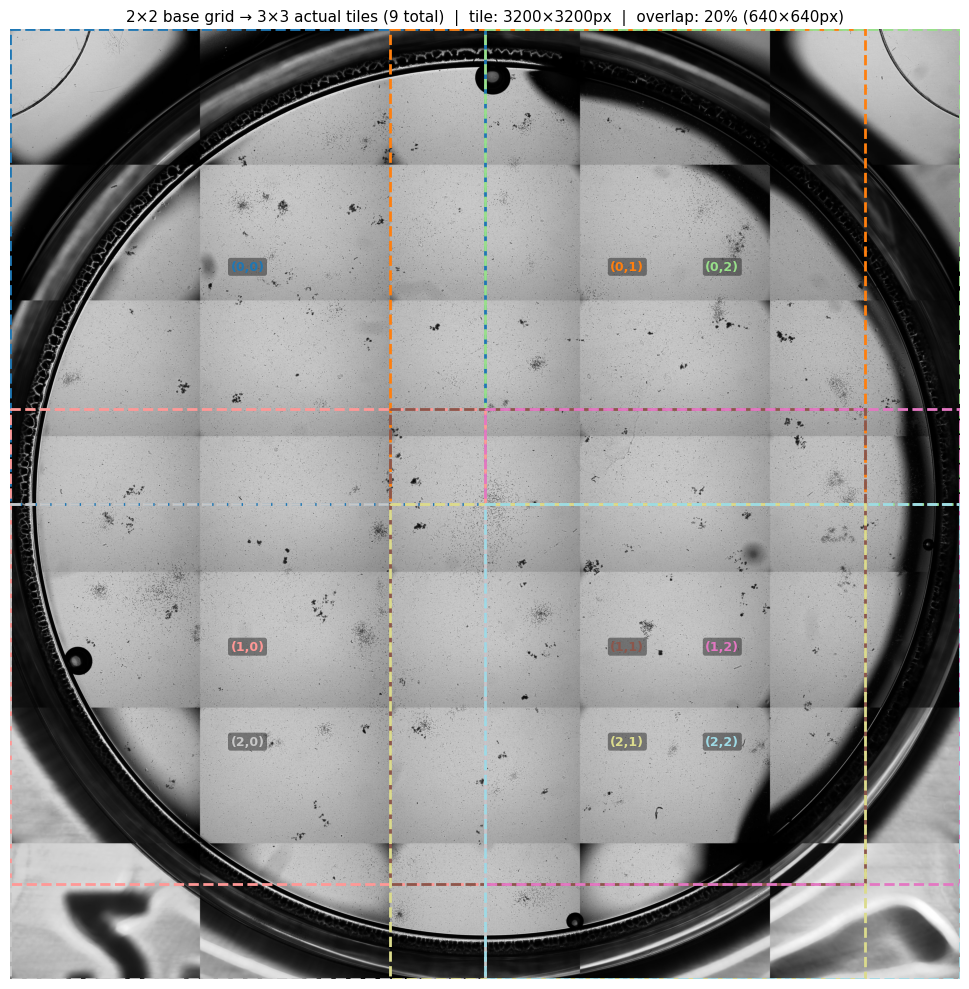

Image: 6400×6400px  |  Total SAHI tiles: 9
X slice starts: [0, 2560, 3200]
Y slice starts: [0, 2560, 3200]


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def get_slice_positions(image_size, tile_size, overlap_ratio):
    """Compute slice start positions using SAHI's stepping formula."""
    step = tile_size * (1 - overlap_ratio)
    positions = []
    x = 0.0
    while x + tile_size <= image_size:
        positions.append(int(round(x)))
        x += step
    if not positions or positions[-1] + tile_size < image_size:
        positions.append(image_size - tile_size)
    return positions


def visualize_tiling(image_path, grid=5, overlap_ratio=0.1):
    """
    Draws every slice that SAHI will produce on a sample image so you can
    verify slicing parameters before running the pipeline.
    """
    img = Image.open(image_path)
    W, H = img.size
    tile_w = W // grid
    tile_h = H // grid
    overlap_w = int(tile_w * overlap_ratio)
    overlap_h = int(tile_h * overlap_ratio)

    x_positions = get_slice_positions(W, tile_w, overlap_ratio)
    y_positions = get_slice_positions(H, tile_h, overlap_ratio)
    n_tiles = len(x_positions) * len(y_positions)

    cmap = plt.cm.get_cmap("tab20", n_tiles)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(img)

    idx = 0
    for row_idx, y in enumerate(y_positions):
        for col_idx, x in enumerate(x_positions):
            color = cmap(idx)
            ax.add_patch(patches.Rectangle(
                (x, y), tile_w, tile_h,
                linewidth=2, edgecolor=color, facecolor='none', linestyle='--'
            ))
            ax.text(
                x + tile_w / 2, y + tile_h / 2,
                f"({row_idx},{col_idx})",
                ha='center', va='center', fontsize=9,
                color=color, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.4, boxstyle='round,pad=0.2', edgecolor='none')
            )
            idx += 1

    ax.set_title(
        f"{grid}×{grid} base grid → {len(y_positions)}×{len(x_positions)} actual tiles "
        f"({n_tiles} total)  |  tile: {tile_w}×{tile_h}px  |  "
        f"overlap: {overlap_ratio*100:.0f}% ({overlap_w}×{overlap_h}px)",
        fontsize=11
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"Image: {W}×{H}px  |  Total SAHI tiles: {n_tiles}")
    print(f"X slice starts: {x_positions}")
    print(f"Y slice starts: {y_positions}")


# --- Edit these to match your intended training parameters ---
SAMPLE_IMAGE    = "/Users/mzhai72/Desktop/SC-RNA Seq/CFU-classifier/data/split/train/images/03.24.26_S1-05-PB0_100k PBMCs per well_plated 03.10.26_2wks#2_A2.jpg"
PREVIEW_GRID    = 2
PREVIEW_OVERLAP = 0.2

visualize_tiling(SAMPLE_IMAGE, grid=PREVIEW_GRID, overlap_ratio=PREVIEW_OVERLAP)